In [35]:
import pandas as pd
from pathlib import Path
from collections import Counter
import numpy as np
from simplemma import text_lemmatizer
import re
import pylangacq
import spacy
# nlp = spacy.load("en_core_web_sm") 
nlp = spacy.load("nl_core_news_lg") 

import matplotlib.pyplot as plt

In [ ]:
class CreativePerplexity():
	def __init__(self, nlp, language, mode, unigram, bigram, constrained_bigram):
		self.nlp = nlp
		self.mode = mode
		self.language = language
		self.unigram = self._load_reference_corpora(unigram)
		self.bigram = self._load_reference_corpora(bigram)
		self.constrained_bigram = self._load_reference_corpora(constrained_bigram)

	def _load_reference_corpora(self, data_path: str) -> pd.DataFrame:
		if Path(data_path).exists():
			return pd.read_csv(data_path)
		
		raise Exception(f'Reference corpora are not registered.')
	
	def _extract_unigrams(self, story, *, with_pos=False,
					 include_punct=False, include_space=False, exclude_pos=None) -> Counter:
		"""
		Return Counter of (lemma,) or (lemma,pos) from the story.
		"""
		doc = self.nlp(story)
		bag = Counter()
		for t in doc:
			if not include_space and t.is_space: 
				continue
			if not include_punct and t.is_punct: 
				continue
			if exclude_pos and t.pos_ in exclude_pos:
				continue
			if with_pos:
				bag[(t.lemma_, t.pos_)] += 1
			else:
				bag[(t.lemma_,)] += 1
		return bag

	def _extract_bigrams(self, story):
		"""
		Return Counter of (lemma_{i-1}, lemma_i) from the story.
		"""
		doc = self.nlp(story)
		pairs = [(doc[i].lemma_, doc[i+1].lemma_) for i in range(len(doc)-1)]

		return Counter(pairs)

	def _collect_dep_pairs(self, node, bag: Counter):
		"""
		Collect linguistically constrained pairs.
		Here: (child -> head) for selected relations.
		Adjust the rules to your needs, but keep orientation consistent with lexicon.
		"""
		# Verbal heads: subject/object relations
		if node.pos_ in ('VERB', 'AUX'):
			for child in node.children:
				if child.dep_ in ('nsubj', 'nsubj:pass', 'obj') and child.text.isalnum():
					try:
						child_lemma = text_lemmatizer(child.text, lang=self.language)[0]
						node_lemma = text_lemmatizer(node.text, lang=self.language)[0]
						bag[(child_lemma, node_lemma)] += 1
					except:
						print(child.text)
						print(node.text)
						raise
		# Nominal heads: adjectival modifiers
		if node.pos_ == 'NOUN':
			for child in node.children:
				if child.dep_ == 'amod' and child.pos_ == 'ADJ' and child.text.isalnum():
					try:
						child_lemma = text_lemmatizer(child.text, lang=self.language)[0]
						node_lemma = text_lemmatizer(node.text, lang=self.language)[0]
						bag[(child_lemma, node_lemma)] += 1
					except:
						print(child.text)
						print(node.text)
						raise

		# Recurse
		for child in node.children:
			self._collect_dep_pairs(child, bag)

	def _extract_dep_pairs(self, story):
		"""
		Return Counter of linguistically constrained (lemma1, lemma2) pairs.
		Current orientation: (dependent lemma, head lemma).
		"""
		bag = Counter()
		for sent in self.nlp(story).sents:
			self._collect_dep_pairs(sent.root, bag)
		return bag

	def _compute_unigram_perplexity_from_counts(
		self,
		story_counts: Counter,
		lexicon,
		*,
		cols=("lemma",),                # or ("lemma","pos")
		alpha: float = 1.0,
		return_frame: bool = False,
	):
		"""
		Unigram PPL with Laplace smoothing:
		p(w) = (c_corpus(w) + alpha) / (C + alpha*V)
		Weighted by story token counts.
		"""
		if not story_counts:
			return (None, pd.DataFrame(columns=[*cols,"count","freq"])) if return_frame else None

		story_df = pd.DataFrame([(*k, c) for k, c in story_counts.items()],
								columns=[*cols, "count"]) \
				.merge(lexicon, how="left", on=list(cols))
		story_df["freq"] = story_df["freq"].fillna(0).astype(np.int64)

		C = int(lexicon["freq"].sum())                                # total tokens in reference
		V = int(lexicon.drop(columns=["freq"]).drop_duplicates().shape[0]) or 1
		denom = C + alpha * V

		p = (story_df["freq"] + alpha) / denom
		logp = np.log(p)

		N = int(story_df["count"].sum())
		ppl = float(np.exp(-(logp * story_df["count"]).sum() / N))

		if return_frame:
			out = story_df.copy()
			out["prob"] = p
			return ppl, out[[*cols, "count", "freq", "prob"]]
		return ppl

	def _compute_perplexity_from_counts(
		self,
		story_counts: Counter,
		lex: pd.DataFrame,       
		*,
		smoothing: str = "kneser_ney",   
		alpha: float = 0.1,              
		unk_token: str = "<unk>",
		return_frame: bool = False
	):
		
		# Fixed vocab for lemma2 (after cutoff)
		vocab2 = set(lex['lemma2'].unique())
		global_V = len(vocab2)

		# ---------- 2) Prepare story pairs and map OOV lemma2 → <unk> ----------
		if not story_counts:
			return (None, pd.DataFrame(columns=['lemma1','lemma2','count'])) if return_frame else None

		def map_l2(l2):
			return l2 if l2 in vocab2 else unk_token

		story_pairs = [ (l1, map_l2(l2), c) for (l1, l2), c in story_counts.items() ]
		story_df = pd.DataFrame(story_pairs, columns=['lemma1','lemma2','count'])
		story_df.at[0, 'lemma2'] = '<unk>'

		# Merge training counts for these pairs
		story_df = story_df.merge(lex, how='left', on=['lemma1','lemma2'])
		story_df['freq'] = story_df['freq'].fillna(0).astype(int)

		# Totals per history
		hist_totals = lex.groupby('lemma1', as_index=False)['freq'].sum().rename(columns={'freq':'hist_total'})
		story_df = story_df.merge(hist_totals, how='left', on='lemma1')
		story_df['hist_total'] = story_df['hist_total'].fillna(0).astype(int)

		# ---------- 3A) Kneser–Ney smoothing ----------
		if smoothing == "kneser_ney":
			# Continuation counts (#distinct w1 per w2)
			cont_df = (
				lex[lex['freq'] > 0]
				.groupby('lemma2', as_index=False)['lemma1']
				.nunique()
				.rename(columns={'lemma1':'cont_count'})
			)
			cont_df = pd.DataFrame({'lemma2': list(vocab2)}).merge(cont_df, how='left', on='lemma2')
			cont_df['cont_count'] = cont_df['cont_count'].fillna(0).astype(int)

			total_types = int((lex['freq'] > 0).sum())
			cont_df['p_cont'] = np.where(
				total_types > 0,
				cont_df['cont_count'] / total_types,
				1.0 / global_V
			)

			story_df = story_df.merge(cont_df[['lemma2','p_cont']], how='left', on='lemma2')
			story_df['p_cont'] = story_df['p_cont'].fillna(1.0 / global_V)

			# Distinct followers per history
			T_df = (
				lex[lex['freq'] > 0]
				.groupby('lemma1', as_index=False)['lemma2']
				.nunique()
				.rename(columns={'lemma2':'T_followers'})
			)
			story_df = story_df.merge(T_df, how='left', on='lemma1')
			story_df['T_followers'] = story_df['T_followers'].fillna(0).astype(int)

			# Discount D
			counts = lex['freq'].values
			N1 = int(np.sum(counts == 1))
			N2 = int(np.sum(counts == 2))
			D = (N1 / (N1 + 2 * N2)) if (N1 + 2 * N2) > 0 else 0.75

			hist = story_df["hist_total"].replace(0, np.nan)  # avoid division by zero
			lam = (D * story_df["T_followers"]) / hist
			lam = lam.fillna(1.0)  # unseen history → full backoff

			hist_safe = story_df['hist_total'].replace(0, np.nan)
			first_term = np.maximum(story_df['freq'] - D, 0.0) / hist_safe
			first_term = first_term.fillna(0.0)

			probs = first_term + lam * story_df['p_cont']
			probs = np.maximum(probs, np.finfo(float).tiny)

			diag_cols = ['lemma1','lemma2','count','freq','hist_total','T_followers','p_cont']
			story_df_out = story_df[diag_cols].copy()
			story_df_out['prob'] = probs

		# ---------- 3B) Add-α smoothing (global) ----------
		elif smoothing == "add_alpha":
			uni = lex.groupby('lemma2', as_index=False)['freq'].sum().rename(columns={'freq':'uni_count'})
			uni = pd.DataFrame({'lemma2': list(vocab2)}).merge(uni, how='left', on='lemma2')
			uni['uni_count'] = uni['uni_count'].fillna(0).astype(int)
			total_uni = int(uni['uni_count'].sum())
			uni['p_unigram'] = (uni['uni_count'] + alpha) / (total_uni + alpha * global_V)

			story_df = story_df.merge(uni[['lemma2','p_unigram']], how='left', on='lemma2')

			denom = story_df['hist_total'] + alpha * global_V
			denom = denom.replace(0, np.nan)  # unseen histories → NaN
			bigram_probs = (story_df['freq'] + alpha) / denom
			probs = bigram_probs.fillna(story_df['p_unigram'])  # backoff to unigram
			probs = np.maximum(probs, np.finfo(float).tiny)

			diag_cols = ['lemma1','lemma2','count','freq','hist_total']
			story_df_out = story_df[diag_cols].copy()
			story_df_out['prob'] = probs

		else:
			raise ValueError("smoothing must be 'kneser_ney' or 'add_alpha'")

		# ---------- 4) Compute perplexity ----------
		N = int(story_df['count'].sum())
		if N == 0:
			return (None, story_df_out) if return_frame else None

		avg_logp = (np.log(probs) * story_df['count']).sum() / N
		ppl = float(np.exp(-avg_logp))

		if return_frame:
			return ppl, story_df_out
		return ppl

	def _perplexity_for_creativity(
		self,
		story: str,
		*,
		alpha: float,
		vocab: str,
		with_pos_unigram: bool,   # unigram extractor option
		unigram_cols,        # or ("lemma","pos") to match your lexicon
		return_frame: bool,
	):
		"""
		General entry point. Chooses the extractor and computes perplexity.
		IMPORTANT: Your lexicon columns must match the extractor/cols:
		- unigram_cols for 'unigram'
		- ['lemma1','lemma2','freq'] for 'bigram'/'dep'
		"""
		if self.mode == "bigram":
			counts = self._extract_bigrams(story)
			return self._compute_perplexity_from_counts(
				counts, self.bigram, alpha=alpha, vocab=vocab, return_frame=return_frame
			)
		elif self.mode == "dep":
			counts = self._extract_dep_pairs(story)
			return self._compute_perplexity_from_counts(
				counts, self.constrained_bigram, alpha=alpha, return_frame=return_frame
			)
		elif self.mode == "unigram":
			counts = self._extract_unigrams(story, with_pos=with_pos_unigram)
			return self._compute_unigram_perplexity_from_counts(
				counts, self.unigram, cols=unigram_cols, alpha=alpha, return_frame=return_frame
			)
		else:
			raise ValueError("mode must be 'unigram', 'bigram', or 'dep'")
	
	def evaluate(self, text: str, vocab="per_history", alpha=1.0, with_pos_unigram=True,
				 unigram_cols=("lemma","pos"), return_frame=False
				 ) -> float:
		return self._perplexity_for_creativity(text,
											   vocab=vocab,
											   alpha=alpha,
											   with_pos_unigram=with_pos_unigram,
											   unigram_cols=unigram_cols,
											   return_frame=return_frame)

In [28]:
path_name = '/Users/sabijn/Documents/PhD/Datasets/chisor_dataset_all/ChiSCor_CoNLL_paper/csv/ChiSCor_master_df_password/ChiSCor_master_df.csv'
df_chiscor = pd.read_csv(path_name, index_col=0)
df_chiscor = df_chiscor.rename(columns={'story_raw': 'story'})

In [29]:
ref_standard_dep = Path('datasets/BasiScript/BS_dep_lexicon_unk_newlemmatizer.csv')
ref_standard_uni = Path('datasets/BasiScript/BS_unigram_lexicon.csv')
ref_standard_bi = Path('datasets/BasiScript/BS_bigram_lexicon.csv')

#  nlp, mode, unigram, bigram, constrained_bigram
ppl = CreativePerplexity(nlp, 'nl', 'dep', ref_standard_uni, ref_standard_bi, ref_standard_dep)

In [30]:
example = "ik mag altijd bij mijn oma op bed spelen.\n"
ppl.evaluate(example)

889.2576364943953

In [31]:
df_chiscor['ppl'] = df_chiscor.apply(lambda row: ppl.evaluate(row['story']), axis = 1) 

In [32]:
df_chiscor['ppl'].mean()

189.36710760998605

In [33]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Download latest version
path = kagglehub.dataset_download("edenbd/children-stories-text-corpus")

included_book_titles = ['The Happy Prince', "Andersen's Fairy Tales", 'The Blue Fairy Book', 'The Adventures of Pinocchio',
'East Indian Stories', 'American Indian Stories', 'MERRY STORIES AND FUNNY PICTURES', 
"Childhood's Favorites and Fairy Stories",'The Wonderful Wizard of Oz', 'Celtic Stories', 'Our Children', 'The Little Lame Prince', 'The Prince and Betty',
'The Adventures of Sherlock Holmes', 'Peter Pan', 'The Secret Garden', 'The Jungle Book', 'The Adventures of Tom Sawyer', 'A Little Princess', 
'Little Women', 'Just So Stories', 'Moby-Dick', 'Treasure Island', 'The Idiot', 'A Tale of Two Cities', 'My Man Jeeves', 'Sense and Sensibility', 
'The Time Machine', 'The Velveteen Rabbit', 'The Book of Dragons', 'The Snow Image', 'The Magical Mimics in Oz',
'Russian Stories', 'Snow-White', 'A Dramatic Reader', 'A Christmas Hamper', "Aesop's Fables", 
"My Father's Dragon", 'The Peace Egg and Other tales', 'Indian Why Stories', 'Folk-Tales of the Khasis', 'The Paradise of Children', 'Wonder Stories',
'The Best American Humorous Short Stories', 'Hindu Tales from the Sanskrit', 'The Tale of Johnny Town-Mouse', 'The Little Red Hen', 'East of the Sun and West of the Moon',
'Among the Forest People', 'True Stories of Wonderful Deeds', 'English Fairy Tales', 'Simla Village Tales Or, Folk Tales from the Himalayas',
'Japanese Fairy Tales', 'Plain Tales of the North', 'The Wind in the Willows', 'A Supplementary Reader for the Fourth Year of School', 
'A Wonder-Book for Girls and Boys', 'Tanglewood Tales', 'The Pig Brother', "The World's Greatest Books", 'Goody Two-Shoes', 
'The Marvelous Exploits of Paul Bunyan', 'Christmas Every Day and Other Stories', "The Children's Book of Thanksgiving Stories"]

included_titles_cleaned = [title.lower().strip('.') for title in included_book_titles]

In [34]:
stories = {}
counter = []

with open(f'/Users/sabijn/Documents/PhD/Datasets/cleaned_merged_fairy_tales_without_eos.txt', 'r') as f:
	for i, line in enumerate(f.readlines()):
		potential_title = line.strip('.;\n ').lower()
		if i == 0:
			current_story = ''
			current_title = potential_title

		if potential_title in included_titles_cleaned:
			stories[current_title] = current_story
			current_story = ''
			current_title = potential_title
		else:
			current_story += line
	
	stories[current_title] = current_story

FileNotFoundError: [Errno 2] No such file or directory: '/Users/sabijn/Documents/PhD/Datasets/cleaned_merged_fairy_tales_without_eos.txt'

In [ ]:
sub_titles = [
	"THE EMPEROR'S NEW CLOTHES ",
	"THE SWINEHERD ",
	"THE REAL PRINCESS ",
	"THE SHOES OF FORTUNE ",
	"THE FIR TREE ",
	"THE SNOW QUEEN ",
	"THE LEAP-FROG ",
	"THE ELDERBUSH ",
	"THE BELL ",
	"THE OLD HOUSE ",
	"THE HAPPY FAMILY ",
	"THE STORY OF A MOTHER ",
	"THE FALSE COLLAR ",
	"THE SHADOW ",
	"THE LITTLE MATCH GIRL ",
	"THE DREAM OF LITTLE TUK ",
	"THE NAUGHTY BOY ",
	"THE RED SHOES ",
	"THE BRONZE RING ",
	"PRINCE HYACINTH AND THE DEAR LITTLE PRINCESS ",
	"THE BLUE BELT ",
	"PRINCE LINDWORM ",
	"THE LASSIE AND HER GODMOTHER ",
	"THE HUSBAND WHO WAS TO MIND THE HOUSE ",
	"THE LAD WHO WENT TO THE NORTH WIND ",
	"THE THREE PRINCESSES OF WHITELAND ",
	"SORIA MORIA CASTLE ",
	"THE GIANT WHO HAD NO HEART IN HIS BODY ",
	"THE PRINCESS ON THE GLASS HILL ",
	"THE WIDOW'S SON ",
	"THE THREE BILLY-GOATS GRUFF ",
	"THE THREE PRINCESSES IN THE BLUE MOUNTAIN ",
	"THE CAT ON THE DOVREFELL ",
	"ONE'S OWN CHILDREN ARE ALWAYS PRETTIEST ",
	"THE UGLY DUCKLING.",
	"THE LITTLE PINE TREE ",
	"THE LITTLE MATCH GIRL.",
	"LITTLE RED RIDING-HOOD.",
	"THE APPLES OF IDUN.",
	"HOW THOR GOT THE HAMMER.",
	"THE HAMMER LOST AND FOUND.",
	"THE STORY OF THE SHEEP.",
	"THE GOOD SHIP ARGO.",
	"JASON AND THE HARPIES.",
	"THE BRASS BULLS.",
	"JASON AND THE DRAGON.",
	"THE FLAX ",
	"THE DAISY ",
	"THE PEA BLOSSOM ",
	"THE STORKS ",
	"THE WILD SWANS ",
	"THE LAST DREAM OF THE OLD OAK ",
	"THE PORTUGUESE DUCK ",
	"THE SNOW MAN ",
	"THE FARMYARD COCK AND THE WEATHERCOCK ",
	"THE LITTLE MERMAID ",
	"BUCKWHEAT ",
	"WHAT HAPPENED TO THE THISTLE ",
	"THE PEN AND THE INKSTAND ",
	"THE TEAPOT ",
	"SOUP FROM A SAUSAGE SKEWER ",
	"WHAT THE GOODMAN DOES IS ALWAYS RIGHT ",
	"THE OLD STREET LAMP ",
	"THE SHEPHERDESS AND THE CHIMNEY SWEEP ",
	"THE DROP OF WATER ",
	"THE METAL PIG ",
	"THE FLYING TRUNK ",
	"THE BUTTERFLY ",
	"THE GOBLIN AND THE HUCKSTER ",
	"EVERYTHING IN ITS RIGHT PLACE ",
	"GREAT CLAUS AND LITTLE CLAUS ",
	"THE THREE BEARS ",
	"CINDERELLA ",
	"THE THREE BROTHERS ",
	"THE WREN AND THE BEAR ",
	"CHICKEN-LICKEN ",
	"THE FOX AND THE CAT ",
	"THE RATS AND THEIR SON-IN-LAW ",
	"THE MOUSE AND THE SAUSAGE ",
	"JOHNNY AND THE GOLDEN GOOSE ",
	"TITTY MOUSE AND TATTY MOUSE ",
	"THE SPIDER AND THE FLEA ",
	"THE LITTLE SHEPHERD BOY ",
	"THE THREE SPINNERS ",
	"THE CAT AND THE MOUSE IN PARTNERSHIP ",
	"THE SWEET SOUP ",
	"THE STRAW THE COAL AND THE BEAN ",
	"WHY THE BEAR HAS A STUMPY TAIL ",
	"THE THREE LITTLE PIGS ",
	"CHILDREN'S FAVORITE POEMS ",
	"THE OWL AND THE PUSSY-CAT ",
	"TWINKLE, TWINKLE ",
	"THE THREE LITTLE KITTENS ",
	"(A CAT'S TALE, WITH ADDITIONS)",
	"THE LAND OF COUNTERPANE ",
	"THERE WAS A LITTLE GIRL ",
	"THE BOY WHO NEVER TOLD A LIE ",
	"THE UNSEEN PLAYMATE ",
	"I SAW THREE SHIPS ",
	"A WAS AN ANT ",
	"THE TABLE AND THE CHAIR ",
	"PRECOCIOUS PIGGY ",
	"A BOY'S SONG ",
	"BUTTERCUPS AND DAISIES ",
	"THE VIOLET ",
	"IF EVER I SEE ",
	"THE LITTLE LAND ",
	"A LOBSTER QUADRILLE ",
	"WHERE GO THE BOATS?",
	"THE WIND AND THE MOON ",
	"WHERE ARE YOU GOING, MY PRETTY MAID?",
	"THE LOST DOLL ",
	"FOREIGN LANDS ",
	"BED IN SUMMER ",
	"TRY AGAIN ",
	"A GOOD PLAY ",
	"GOOD NIGHT AND GOOD MORNING ",
	"THE WIND ",
	"THE SPIDER AND THE FLY ",
	"LET DOGS DELIGHT TO BARK AND BITE ",
	"CHILD'S EVENING HYMN ",
	"CHILDREN'S FAVORITE STORIES ",
	"HANSEL AND GRETEL ",
	"PUSS IN BOOTS ",
	"THE ELVES AND THE SHOEMAKER ",
	"HANS IN LUCK ",
	"BELLING THE CAT ",
	"JACK AND THE BEANSTALK ",
	"THE SLEEPING BEAUTY ",
	"OLD-FASHIONED POEMS ",
	"LIMERICKS ",
	"MORE LIMERICKS ",
	"THE DEAD DOLL ",
	"THE GOLDEN RULE ",
	"THANKSGIVING DAY ",
	"THE MAGPIE'S NEST ",
	"THE FAIRIES OF THE CALDON LOW ",
	"THE LAND OF STORY-BOOKS ",
	"A VISIT FROM ST. NICHOLAS ",
	"LITTLE ORPHANT ANNIE ",
	"THE CHATTERBOX ",
	"THE VOICE OF SPRING ",
	"THE HISTORY LESSON ",
	"SONG OF LIFE ",
	"THE GOOD TIME COMING ",
	"WINDY NIGHTS ",
	"THE WONDERFUL WORLD ",
	"HARK! HARK! THE LARK ",
	"JOG ON, JOG ON ",
	"MY SHADOW ",
	"BY COOL SILOAM'S SHADY RILL ",
	"THE WIND IN A FROLIC ",
	"THE GRAVES OF A HOUSEHOLD ",
	"WE ARE SEVEN ",
	"THE BETTER LAND ",
	"THE JUVENILE ORATOR ",
	"THE FOX AND THE CROW ",
	"THE USE OF FLOWERS ",
	"CONTENTED JOHN ",
	"THE OLD MAN'S COMFORTS, AND HOW HE GAINED THEM ",
	"THE FROST ",
	"THE BATTLE OF BLENHEIM ",
	"THE CHAMELEON ",
	"THE HARDY TIN SOLDIER ",
	"THUMBELINA ",
	"THE TINDER-BOX ",
	"BOOTS AND HIS BROTHERS ",
	"THE FISHERMAN AND HIS WIFE ",
	"LITTLE SNOW-WHITE ",
	"BEAUTY AND THE BEAST ",
	"THE HISTORY OF TOM THUMB ",
	"PINOCCHIO'S ADVENTURES IN WONDERLAND",
	"HOW THE CAMEL GOT HIS HUMP ",
	"HOW THE RHINOCEROS GOT HIS SKIN ",
	"HOW THE LEOPARD GOT HIS SPOTS ",
	"THE ELEPHANT’S CHILD ",
	"THE CAT THAT WALKED BY HIMSELF ",
	"THE PIED PIPER ",
	"THE GINGERBREAD MAN ",
	"THE TALE OF PETER RABBIT ",
	"THE STORY OF PETER PAN ",
	"THE BIRD WITH THE BROKEN WING ",
	"GOLDILOCKS, OR THE THREE BEARS ",
	"CHRISTMAS EVERY DAY.",
	"THE PUMPKIN-GLORY "
]

non_kids_books = [
	'moby-dick',
	'the idiot',
	'a tale of two cities',
	'my man jeeves',
	'sense and sensibility',
	'the time machine',
	'plain tales of the north',
	'the best american humorous short stories',
	"the world's greatest books",
]


In [ ]:
kids_stories = {title: story for title, story in stories.items() if title not in non_kids_books}

In [ ]:
counter = 0
filtered_kids_stories = {}
substory = False

for name, story in kids_stories.items():
	substory = False
	current_story = ''
	current_title = name
	
	# find substories
	for line in story.split('\n'):
		if line.startswith('BY') or line.startswith('ADAPTED'):
			continue

		if line in sub_titles:
			substory = True
			if current_story == '':
				current_title = line.strip('.;\n ').lower()
			else:
				filtered_kids_stories[current_title] = current_story
				current_title = line.strip('.;\n ').lower()
				current_story = ''
		else:
			current_story += line

	# clean-up
	if substory:
		filtered_kids_stories[current_title] = current_story
	else:
		filtered_kids_stories[name] = story

In [ ]:
df_kids_stories = pd.DataFrame.from_dict(filtered_kids_stories, orient='index', columns=['value'])
df_kids_stories = df_kids_stories.reset_index().rename(columns={'index': 'title'})
df_kids_stories.rename(columns={'value':'story'}, inplace=True)
df_kids_stories

,title,story
0,the happy prince,"HIGH above the city, on a tall column, stood t..."
1,the emperor's new clothes,MANY years ago there was an emperor who was so...
2,the swineherd,THERE was once a poor prince who had a kingdom...
3,the real princess,THERE was once a prince who wanted to marry a ...
4,the shoes of fortune,I. A Beginning Every author has some peculiari...
...,...,...
228,the marvelous exploits of paul bunyan,Paul Bunyan \nScholars Say He is the Only Amer...
229,christmas every day and other stories,...
230,christmas every day,"The little girl came into her papa's study, as..."
231,the pumpkin-glory,The papa had told the story so often that the ...


In [ ]:
df_kids_stories['story_length'] = df_kids_stories['story'].str.split().str.len()
df = df_kids_stories[df_kids_stories['story_length'] > 0]

df_short_kids = df_kids_stories[df_kids_stories['story_length'] < 10000]

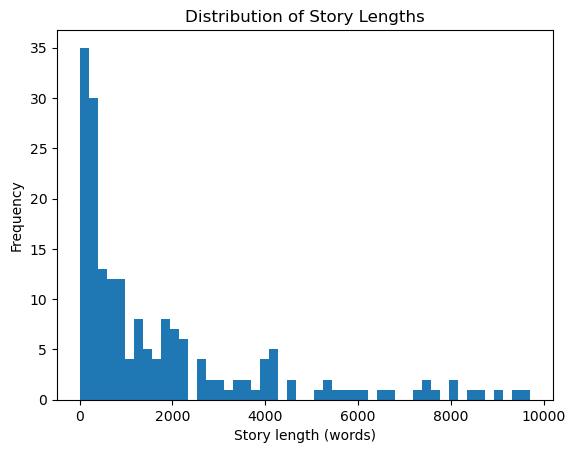

In [ ]:
plt.figure()
plt.hist(df_short_kids['story_length'], bins=50)
plt.xlabel('Story length (words)')
plt.ylabel('Frequency')
plt.title('Distribution of Story Lengths')
plt.show()


In [ ]:
df_short_kids = df_kids_stories[df_kids_stories['story_length'] < 10000]
df_short_kids

,title,story,story_length
1,the emperor's new clothes,MANY years ago there was an emperor who was so...,1680
2,the swineherd,THERE was once a poor prince who had a kingdom...,1473
3,the real princess,THERE was once a prince who wanted to marry a ...,376
5,the fir tree,Out in the forest stood a pretty little Fir Tr...,4229
7,the leap-frog,"A Flea, a Grasshopper, and a Leap-frog once wa...",653
...,...,...,...
226,the pig brother,There was once a child who was untidy. He left...,4529
228,the marvelous exploits of paul bunyan,Paul Bunyan \nScholars Say He is the Only Amer...,9714
229,christmas every day and other stories,...,181
230,christmas every day,"The little girl came into her papa's study, as...",8409


In [ ]:
df_kids_stories['title'][df_kids_stories['story_length'] == 0]

123    children's favorite stories
Name: title, dtype: object

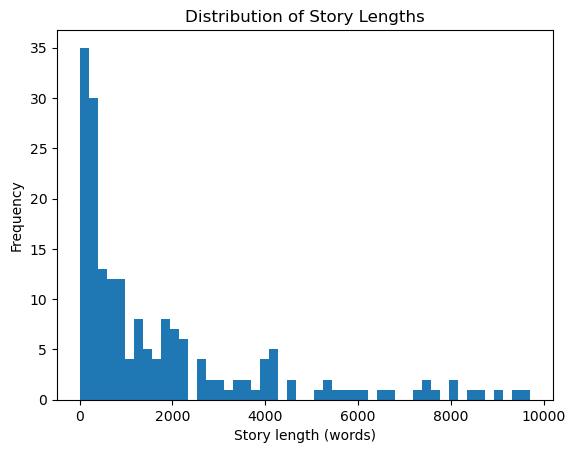

In [ ]:
plt.figure()
plt.hist(df_short_kids['story_length'], bins=50)
plt.xlabel('Story length (words)')
plt.ylabel('Frequency')
plt.title('Distribution of Story Lengths')
plt.show()